In [2]:
!pip install kaggle -q

from google.colab import files
files.upload()  # Upload kaggle.json from your machine

!mkdir -p ~/.kaggle
!cp KGAT_3bf557974448d8ad75d93520c2a31434 ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving spam.csv to spam (1).csv
cp: cannot stat 'KGAT_3bf557974448d8ad75d93520c2a31434': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [3]:
!kaggle datasets download -d uciml/sms-spam-collection-dataset
!unzip sms-spam-collection-dataset.zip
!ls

Dataset URL: https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
License(s): unknown
100% 211k/211k [00:00<00:00, 118MB/s]

Archive:  sms-spam-collection-dataset.zip
replace spam.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: spam.csv                
 sample_data   sms-spam-collection-dataset.zip	'spam (1).csv'	 spam.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import warnings
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords')
nltk.download('punkt')
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

# Feature Extraction
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

# Models
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

# Evaluation
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

print("All libraries imported ✅")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All libraries imported ✅


In [5]:
# Load dataset
df = pd.read_csv('spam.csv', encoding='latin-1')

# Drop unnamed columns (dataset has extra cols)
df = df[['v1', 'v2']]
df.columns = ['label', 'message']

print("Shape:", df.shape)
print("\nFirst 5 rows:")
df.head()

Shape: (5572, 2)

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam %: 13.4%


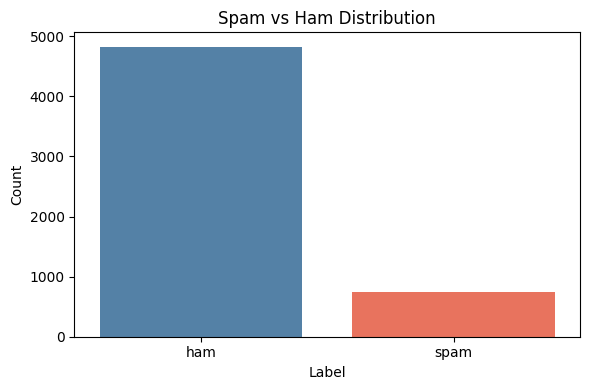

In [6]:
# Class distribution
print("Label Distribution:")
print(df['label'].value_counts())
print(f"\nSpam %: {df['label'].value_counts(normalize=True)['spam']*100:.1f}%")

# Visualize
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=df, palette=['steelblue', 'tomato'])
plt.title('Spam vs Ham Distribution')
plt.xlabel('Label')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

      msg_length                                                  word_count  \
           count    mean    std   min    25%    50%    75%    max      count   
label                                                                          
ham       4825.0   71.02  58.02   2.0   33.0   52.0   92.0  910.0     4825.0   
spam       747.0  138.87  29.18  13.0  132.5  149.0  157.0  224.0      747.0   

                                                   
        mean    std  min   25%   50%   75%    max  
label                                              
ham    14.20  11.42  1.0   7.0  11.0  19.0  171.0  
spam   23.85   5.81  2.0  22.0  25.0  28.0   35.0  


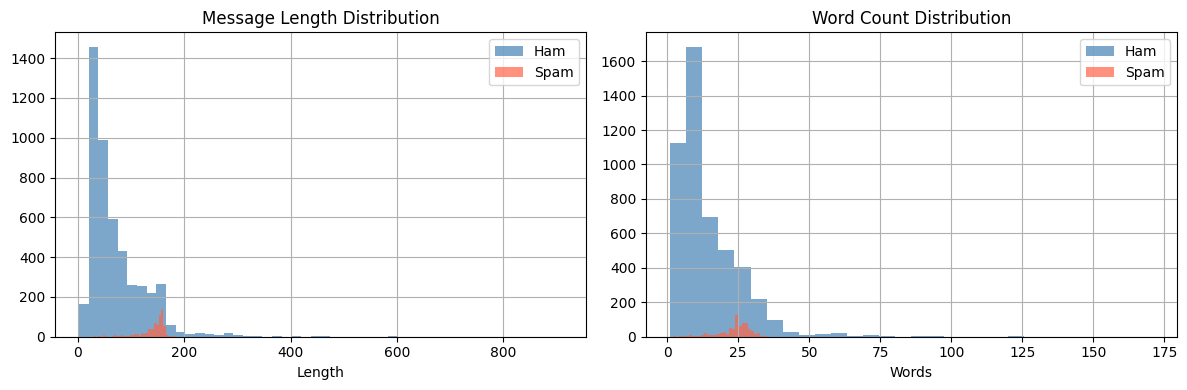

In [7]:
# Message length analysis
df['msg_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))

print(df.groupby('label')[['msg_length', 'word_count']].describe().round(2))

# Length distribution
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df[df['label']=='ham']['msg_length'].hist(bins=50, color='steelblue', alpha=0.7, label='Ham')
df[df['label']=='spam']['msg_length'].hist(bins=50, color='tomato', alpha=0.7, label='Spam')
plt.legend()
plt.title('Message Length Distribution')
plt.xlabel('Length')

plt.subplot(1, 2, 2)
df[df['label']=='ham']['word_count'].hist(bins=30, color='steelblue', alpha=0.7, label='Ham')
df[df['label']=='spam']['word_count'].hist(bins=30, color='tomato', alpha=0.7, label='Spam')
plt.legend()
plt.title('Word Count Distribution')
plt.xlabel('Words')

plt.tight_layout()
plt.show()

In [8]:
stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    # 1. Lowercase
    text = text.lower()

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Remove email addresses
    text = re.sub(r'\S+@\S+', '', text)

    # 4. Remove phone numbers
    text = re.sub(r'\b\d{10,}\b', '', text)

    # 5. Remove punctuation & special chars
    text = re.sub(r'[^a-z\s]', '', text)

    # 6. Tokenize
    tokens = text.split()

    # 7. Remove stopwords + stem
    tokens = [stemmer.stem(word) for word in tokens if word not in stop_words and len(word) > 2]

    return ' '.join(tokens)

# Apply preprocessing
df['cleaned'] = df['message'].apply(preprocess_text)

# Preview
print("Original:\n", df['message'][0])
print("\nCleaned:\n", df['cleaned'][0])

Original:
 Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...

Cleaned:
 jurong point crazi avail bugi great world buffet cine got amor wat


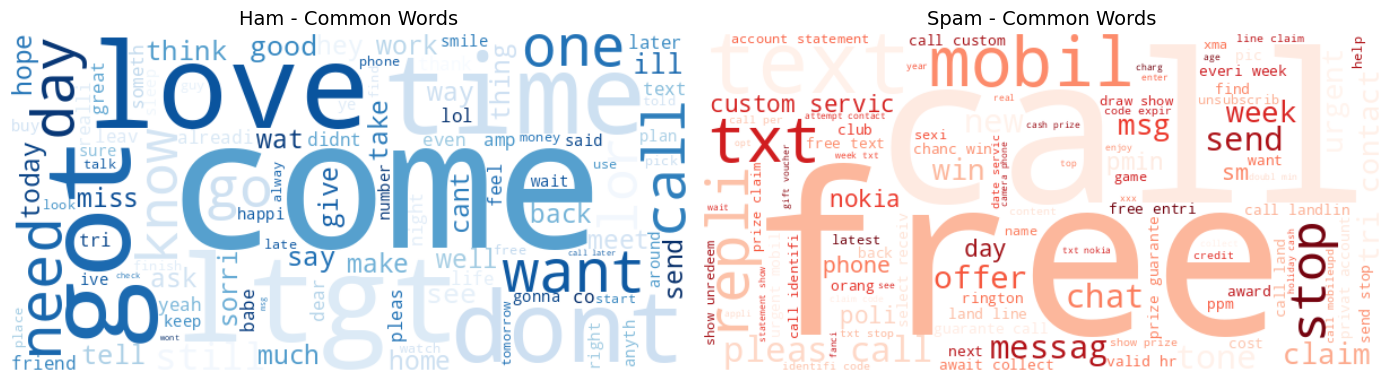

In [9]:
# WordCloud for visual insight
!pip install wordcloud -q
from wordcloud import WordCloud

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, label, color in zip(axes, ['ham', 'spam'], ['Blues', 'Reds']):
    text = ' '.join(df[df['label'] == label]['cleaned'])
    wc = WordCloud(width=600, height=300, background_color='white', colormap=color, max_words=100)
    wc.generate(text)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{"Ham" if label == "ham" else "Spam"} - Common Words', fontsize=14)

plt.tight_layout()
plt.show()

In [10]:
# Encode labels
df['label_enc'] = df['label'].map({'ham': 0, 'spam': 1})

X = df['cleaned']
y = df['label_enc']

# Train-test split (80/20, stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {len(X_train)}")
print(f"Test size:  {len(X_test)}")
print(f"Spam in test: {y_test.sum()} / {len(y_test)}")

Train size: 4457
Test size:  1115
Spam in test: 149 / 1115


In [11]:
# TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,      # Top 5000 words
    ngram_range=(1, 2),     # Unigrams + Bigrams
    min_df=2,               # Ignore very rare terms
    sublinear_tf=True       # Apply log normalization
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf  = tfidf.transform(X_test)

print(f"Feature matrix shape: {X_train_tfidf.shape}")

Feature matrix shape: (4457, 5000)


In [12]:
models = {
    'Naive Bayes (Multinomial)': MultinomialNB(alpha=0.1),
    'Logistic Regression':       LogisticRegression(max_iter=1000, C=1.0),
    'Linear SVM':                LinearSVC(C=1.0, max_iter=1000),
    'Random Forest':             RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    y_pred = model.predict(X_test_tfidf)

    results[name] = {
        'Accuracy':  accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall':    recall_score(y_test, y_pred),
        'F1 Score':  f1_score(y_test, y_pred)
    }
    print(f"\n{'='*40}")
    print(f"  {name}")
    print(f"{'='*40}")
    print(f"  Accuracy:  {results[name]['Accuracy']:.4f}")
    print(f"  Precision: {results[name]['Precision']:.4f}")
    print(f"  Recall:    {results[name]['Recall']:.4f}")
    print(f"  F1 Score:  {results[name]['F1 Score']:.4f}")


  Naive Bayes (Multinomial)
  Accuracy:  0.9767
  Precision: 0.9624
  Recall:    0.8591
  F1 Score:  0.9078

  Logistic Regression
  Accuracy:  0.9641
  Precision: 0.9580
  Recall:    0.7651
  F1 Score:  0.8507

  Linear SVM
  Accuracy:  0.9839
  Precision: 0.9712
  Recall:    0.9060
  F1 Score:  0.9375

  Random Forest
  Accuracy:  0.9749
  Precision: 0.9840
  Recall:    0.8255
  F1 Score:  0.8978


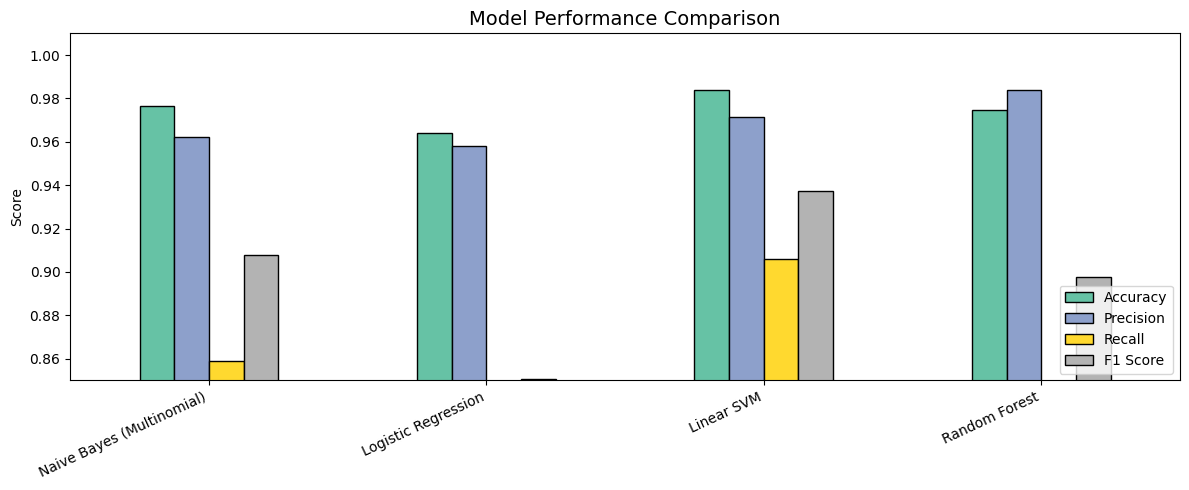

In [13]:
results_df = pd.DataFrame(results).T
results_df.plot(kind='bar', figsize=(12, 5), colormap='Set2', edgecolor='black')
plt.title('Model Performance Comparison', fontsize=14)
plt.ylabel('Score')
plt.ylim(0.85, 1.01)
plt.xticks(rotation=25, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

Best Model: Linear SVM



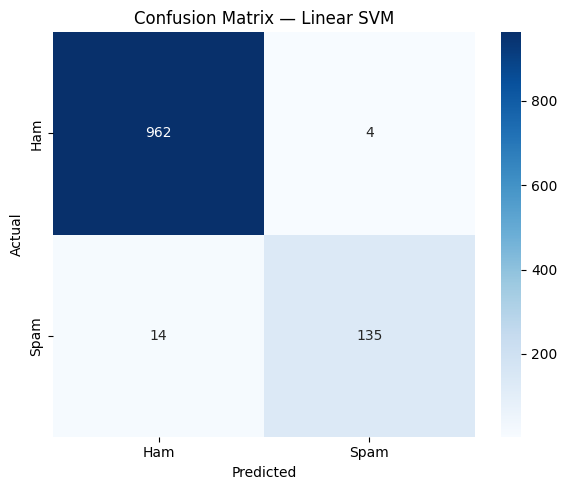


Detailed Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      1.00      0.99       966
        Spam       0.97      0.91      0.94       149

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [14]:
# Logistic Regression or SVM usually wins — pick best F1
best_name = max(results, key=lambda k: results[k]['F1 Score'])
best_model = models[best_name]

print(f"Best Model: {best_name}\n")

y_pred_best = best_model.predict(X_test_tfidf)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title(f'Confusion Matrix — {best_name}')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_best, target_names=['Ham', 'Spam']))

In [15]:
cv_scores = cross_val_score(best_model,
                             tfidf.transform(df['cleaned']),
                             df['label_enc'],
                             cv=5, scoring='f1')

print(f"5-Fold Cross-Validation F1 Scores: {cv_scores.round(4)}")
print(f"Mean F1: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")

5-Fold Cross-Validation F1 Scores: [0.9306 0.9181 0.9395 0.9214 0.8842]
Mean F1: 0.9188 ± 0.0188


In [16]:
def predict_spam(message, model, vectorizer):
    cleaned = preprocess_text(message)
    features = vectorizer.transform([cleaned])
    prediction = model.predict(features)[0]

    # Probability (works for models with predict_proba)
    try:
        prob = model.predict_proba(features)[0]
        confidence = max(prob) * 100
        print(f"Message: {message[:60]}...")
        print(f"Prediction: {'🚨 SPAM' if prediction == 1 else '✅ HAM (Not Spam)'}")
        print(f"Confidence: {confidence:.1f}%\n")
    except:
        print(f"Prediction: {'🚨 SPAM' if prediction == 1 else '✅ HAM (Not Spam)'}\n")

# Test it
test_messages = [
    "Congratulations! You've won a FREE iPhone. Click here to claim your prize now!!!",
    "Hey, are we still on for lunch tomorrow at 1pm?",
    "URGENT: Your account has been suspended. Verify immediately to avoid charges.",
    "Can you send me the assignment notes for tomorrow's class?",
    "Win $1000 cash prize! Text WIN to 88888 now. Limited time offer!"
]

for msg in test_messages:
    predict_spam(msg, best_model, tfidf)

Prediction: 🚨 SPAM

Prediction: ✅ HAM (Not Spam)

Prediction: ✅ HAM (Not Spam)

Prediction: ✅ HAM (Not Spam)

Prediction: 🚨 SPAM



In [17]:
# Save your notebook
# File → Download → Download .ipynb

# If you want to also save the trained model:
import joblib
joblib.dump(best_model, 'spam_classifier_model.pkl')
joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

from google.colab import files
files.download('spam_classifier_model.pkl')
files.download('tfidf_vectorizer.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>